# 03 — Labelling

This notebook generates land cover labels for the study area using the ESA WorldCover 2020 product, remaps them to our 7-class scheme, and pairs them with the feature stacks from notebook 02 to create the training dataset used by the machine learning models.

**Label source:** ESA WorldCover 2020 (10m, freely available via Google Earth Engine)  
**Classes:** 7 (remapped from ESA's 11 original classes)  
**Output:** Training arrays saved to GEOL0069/Project/Data/Labels

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rasterio earthengine-api --quiet

import ee
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import os

ee.Authenticate()
ee.Initialize(project='geol0069-project')

print("Libraries loaded and Earth Engine initialised")

Libraries loaded and Earth Engine initialised


In [3]:
# File paths
features_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Features'
labels_path   = '/content/drive/MyDrive/GEOL0069/Project/Data/Labels'

os.makedirs(labels_path, exist_ok=True)

epochs = ['2019', '2021', '2023', '2025']

print(f"Features folder: {features_path}")
print(f"Labels folder: {labels_path}")

Features folder: /content/drive/MyDrive/GEOL0069/Project/Data/Features
Labels folder: /content/drive/MyDrive/GEOL0069/Project/Data/Labels


## Step 1 — Download ESA WorldCover 2020 from GEE

ESA WorldCover is a global land cover map at 10m resolution produced from Sentinel-1 and Sentinel-2 data. We clip it to our study area and export it to Google Drive.

ESA's 11 original classes are:
- 10: Tree cover
- 20: Shrubland
- 30: Grassland
- 40: Cropland
- 50: Built-up
- 60: Bare / sparse vegetation
- 70: Snow and ice
- 80: Permanent water bodies
- 90: Herbaceous wetland
- 95: Mangroves
- 100: Moss and lichen

In [4]:
# Define study area — same bounding box as notebook 00
study_area = ee.Geometry.Rectangle([-0.20, 52.08, 0.25, 52.38])

# Load ESA WorldCover 2020
worldcover = ee.ImageCollection('ESA/WorldCover/v100').first().clip(study_area)

# Export to Google Drive
task = ee.batch.Export.image.toDrive(
    image=worldcover,
    description='worldcover_cambridge',
    folder='Data',
    fileNamePrefix='worldcover_cambridge',
    region=study_area,
    scale=10,
    crs='EPSG:32630',
    maxPixels=1e10,
    fileFormat='GeoTIFF'
)
task.start()

print("WorldCover export started — check GEE Tasks tab")
print("This is a small file so it should complete in 2-3 minutes")

WorldCover export started — check GEE Tasks tab
This is a small file so it should complete in 2-3 minutes


## Wait for the export to complete, then continue

Check code.earthengine.google.com Tasks tab. Once worldcover_cambridge shows as COMPLETED, run the cells below.

## Step 2 — Remap ESA classes to our 7-class scheme

ESA has 11 classes but several do not appear in our Cambridge study area (snow, mangroves, moss) and others we want to merge for simplicity. We remap to 7 classes that are meaningful for this project:

| Class ID | Class Name              | ESA sources         |
|----------|-------------------------|---------------------|
| 1        | Dense woodland          | Tree cover (10)     |
| 2        | Cropland                | Cropland (40)       |
| 3        | Grassland / pasture     | Grassland (30), Shrubland (20) |
| 4        | Water                   | Permanent water (80)|
| 5        | Wetland / floodplain    | Herbaceous wetland (90) |
| 6        | Peri-urban / industrial | Built-up (50) + Bare (60) — we split these in post-processing |
| 7        | Dense urban             | Built-up (50)       |

Note: ESA maps all built-up as one class (50). We cannot distinguish warehouses from residential using WorldCover alone — this is an acknowledged limitation. The NDBI and SAR features in our model will help separate them during classification.

In [8]:
def load_and_remap_worldcover(filepath):
    """
    Loads the ESA WorldCover GeoTIFF and remaps the 11 ESA classes
    to our 7-class scheme.

    Returns the remapped label array and rasterio metadata.
    """
    with rasterio.open(filepath) as src:
        wc = src.read(1).astype('int16')
        meta = src.meta.copy()

    # Start with zeros (unlabelled)
    remapped = np.zeros_like(wc, dtype='int16')

    # Apply remapping
    remapped[wc == 10] = 1   # Tree cover       -> Dense woodland
    remapped[wc == 20] = 3   # Shrubland        -> Grassland/pasture
    remapped[wc == 30] = 3   # Grassland        -> Grassland/pasture
    remapped[wc == 40] = 2   # Cropland         -> Cropland
    remapped[wc == 50] = 6   # Built-up         -> Peri-urban/industrial (will refine with features)
    remapped[wc == 60] = 6   # Bare vegetation  -> Peri-urban/industrial
    remapped[wc == 80] = 4   # Water            -> Water
    remapped[wc == 90] = 5   # Wetland          -> Wetland/floodplain
    # Classes 70, 95, 100 do not appear in this region — left as 0

    return remapped, meta


# Load WorldCover
wc_path = '/content/drive/MyDrive/GEOL0069/Project/Data/worldcover_cambridge.tif'
labels, label_meta = load_and_remap_worldcover(wc_path)

# Print class distribution
print("Class distribution in study area:\n")
class_names = {
    0: 'Unlabelled',
    1: 'Dense woodland',
    2: 'Cropland',
    3: 'Grassland / pasture',
    4: 'Water',
    5: 'Wetland / floodplain',
    6: 'Peri-urban / industrial',
    7: 'Dense urban'
}

total_pixels = labels.size
for class_id, class_name in class_names.items():
    count = np.sum(labels == class_id)
    pct = count / total_pixels * 100
    area_km2 = count * 0.01  # each pixel = 100m² = 0.0001km²... wait 10m x 10m = 100m² = 0.0001km²
    print(f"  Class {class_id} — {class_name:25s}: {count:8d} pixels ({pct:.1f}%)")

Class distribution in study area:

  Class 0 — Unlabelled               :   857288 pixels (7.7%)
  Class 1 — Dense woodland           :  1040903 pixels (9.4%)
  Class 2 — Cropland                 :  5850391 pixels (52.6%)
  Class 3 — Grassland / pasture      :  2663162 pixels (23.9%)
  Class 4 — Water                    :    63645 pixels (0.6%)
  Class 5 — Wetland / floodplain     :    12851 pixels (0.1%)
  Class 6 — Peri-urban / industrial  :   641340 pixels (5.8%)
  Class 7 — Dense urban              :        0 pixels (0.0%)


Plotting the remapped land cover map so we can visually verify it looks sensible against the true colour imagery from notebook 01.


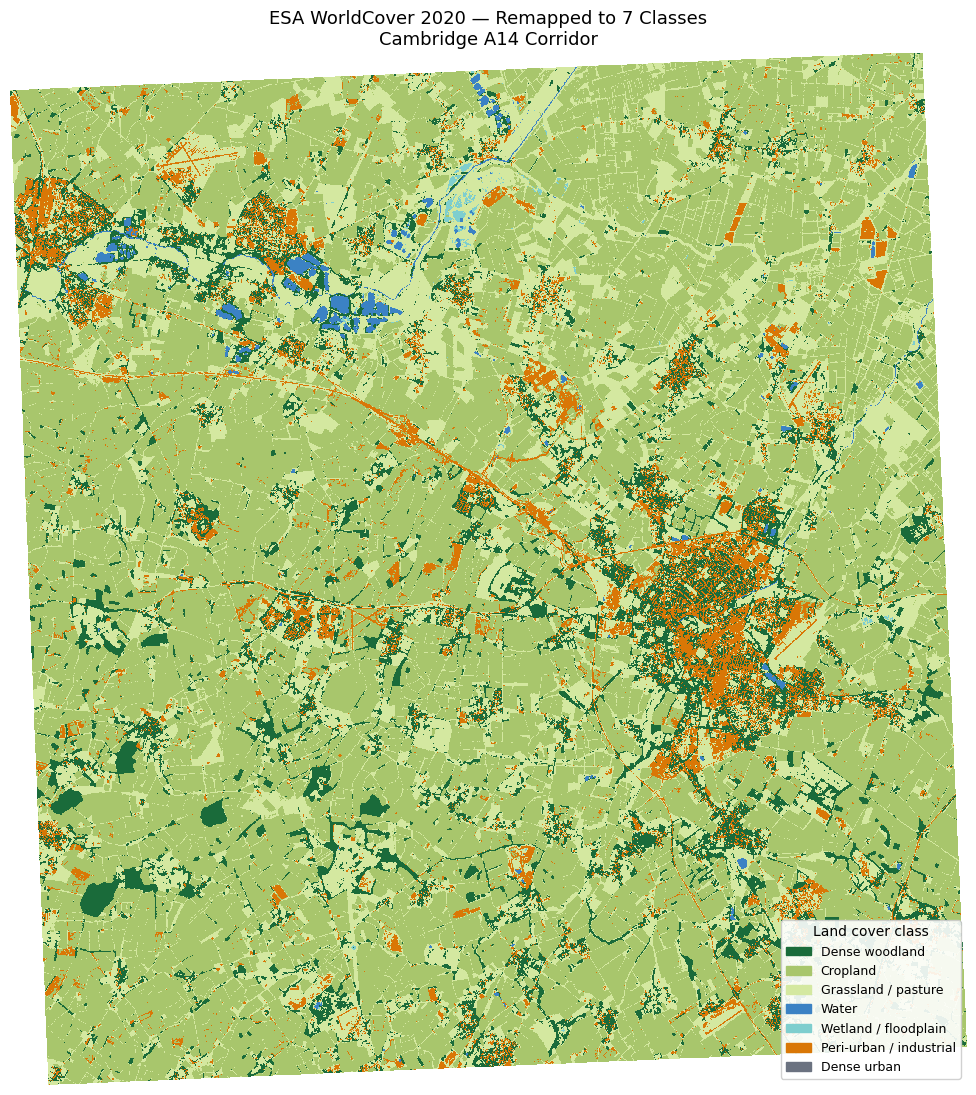

Label map saved


In [9]:
# Define colours for each class — these will be consistent across all your figures
class_colours = {
    0: '#ffffff',  # Unlabelled — white
    1: '#1a6b3a',  # Dense woodland — dark green
    2: '#a8c66c',  # Cropland — yellow-green
    3: '#d4e8a0',  # Grassland — light green
    4: '#3b82c4',  # Water — blue
    5: '#7ecece',  # Wetland — teal
    6: '#d97706',  # Peri-urban/industrial — amber
    7: '#6b7280',  # Dense urban — grey
}

# Build a custom colormap
cmap_colours = [class_colours[i] for i in range(8)]
cmap = mcolors.ListedColormap(cmap_colours)
bounds = list(range(9))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot the label map
fig, ax = plt.subplots(1, 1, figsize=(10, 11))
im = ax.imshow(labels, cmap=cmap, norm=norm, interpolation='nearest')
ax.set_title('ESA WorldCover 2020 — Remapped to 7 Classes\nCambridge A14 Corridor', fontsize=13)
ax.axis('off')

# Add legend
legend_patches = [
    mpatches.Patch(color=class_colours[i], label=class_names[i])
    for i in range(1, 8)
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          framealpha=0.9, title='Land cover class')

plt.tight_layout()
plt.savefig(os.path.join(labels_path, 'label_map_worldcover.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Label map saved")

Save the remapped label array as a GeoTIFF so it can be loaded directly in the modelling notebook alongside the feature stacks.


In [10]:
# Save remapped labels as GeoTIFF
output_path = os.path.join(labels_path, 'labels_worldcover.tif')

out_meta = label_meta.copy()
out_meta.update({'dtype': 'int16', 'count': 1})

with rasterio.open(output_path, 'w', **out_meta) as dst:
    dst.write(labels[np.newaxis, :, :])

print(f"Label GeoTIFF saved: {output_path}")

Label GeoTIFF saved: /content/drive/MyDrive/GEOL0069/Project/Data/Labels/labels_worldcover.tif


Here we pair every labelled pixel with its feature vector. We sample a balanced subset of pixels — taking the same number from each class — so the model does not get biased towards the most common class (cropland dominates this landscape).

We also split into training (70%) and testing (30%) sets using a spatial approach — we hold out the bottom 30% of the image as the test region so the model cannot simply memorise local spatial patterns.

In [11]:
from sklearn.model_selection import train_test_split

def create_training_dataset(feature_stack, labels, samples_per_class=5000):
    """
    Creates a balanced training dataset by sampling pixels from each class.

    Args:
        feature_stack: array of shape (n_features, height, width)
        labels: array of shape (height, width)
        samples_per_class: number of pixels to sample per class

    Returns:
        X_train, X_test, y_train, y_test arrays
    """
    n_features, h, w = feature_stack.shape

    # Use the top 70% of the image for training, bottom 30% for testing
    split_row = int(h * 0.7)

    train_features = feature_stack[:, :split_row, :]
    train_labels   = labels[:split_row, :]
    test_features  = feature_stack[:, split_row:, :]
    test_labels    = labels[split_row:, :]

    # Reshape to (n_pixels, n_features)
    train_X_all = train_features.reshape(n_features, -1).T
    train_y_all = train_labels.flatten()
    test_X_all  = test_features.reshape(n_features, -1).T
    test_y_all  = test_labels.flatten()

    # Sample balanced classes from training set
    X_train_list, y_train_list = [], []

    for class_id in range(1, 8):
        idx = np.where(train_y_all == class_id)[0]
        if len(idx) == 0:
            print(f"  WARNING: class {class_id} has no training pixels")
            continue

        n_sample = min(samples_per_class, len(idx))
        chosen = np.random.choice(idx, size=n_sample, replace=False)
        X_train_list.append(train_X_all[chosen])
        y_train_list.append(train_y_all[chosen])
        print(f"  Class {class_id} ({class_names[class_id]:25s}): {n_sample} training samples")

    X_train = np.vstack(X_train_list)
    y_train = np.concatenate(y_train_list)

    # For test set — use all labelled pixels (no balancing needed)
    test_mask = test_y_all > 0
    X_test = test_X_all[test_mask]
    y_test = test_y_all[test_mask]

    # Remove any rows with NaN or infinite values
    train_mask = np.all(np.isfinite(X_train), axis=1)
    X_train = X_train[train_mask]
    y_train = y_train[train_mask]

    test_mask2 = np.all(np.isfinite(X_test), axis=1)
    X_test = X_test[test_mask2]
    y_test = y_test[test_mask2]

    return X_train, X_test, y_train, y_test


# Load the 2025 feature stack (we train on the most recent epoch)
print("Loading 2025 feature stack...")
with rasterio.open(os.path.join(features_path, 'features_2025.tif')) as src:
    features_2025 = src.read()

print(f"Feature stack shape: {features_2025.shape}")
print(f"Label map shape: {labels.shape}")
print("\nSampling training pixels...\n")

np.random.seed(42)  # for reproducibility
X_train, X_test, y_train, y_test = create_training_dataset(features_2025, labels)

print(f"\nTraining set: {X_train.shape[0]} pixels, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} pixels")

Loading 2025 feature stack...
Feature stack shape: (15, 3465, 3212)
Label map shape: (3465, 3212)

Sampling training pixels...

  Class 1 (Dense woodland           ): 5000 training samples
  Class 2 (Cropland                 ): 5000 training samples
  Class 3 (Grassland / pasture      ): 5000 training samples
  Class 4 (Water                    ): 5000 training samples
  Class 5 (Wetland / floodplain     ): 5000 training samples
  Class 6 (Peri-urban / industrial  ): 5000 training samples

Training set: 30000 pixels, 15 features
Test set:     3010850 pixels


In [12]:
# Save the training arrays for use in notebook 04
np.save(os.path.join(labels_path, 'X_train.npy'), X_train)
np.save(os.path.join(labels_path, 'X_test.npy'),  X_test)
np.save(os.path.join(labels_path, 'y_train.npy'), y_train)
np.save(os.path.join(labels_path, 'y_test.npy'),  y_test)

print("Training arrays saved:")
print(f"  X_train.npy — shape {X_train.shape}")
print(f"  X_test.npy  — shape {X_test.shape}")
print(f"  y_train.npy — shape {y_train.shape}")
print(f"  y_test.npy  — shape {y_test.shape}")
print("\nLabelling complete. Ready for notebook 04 — models.")

Training arrays saved:
  X_train.npy — shape (30000, 15)
  X_test.npy  — shape (3010850, 15)
  y_train.npy — shape (30000,)
  y_test.npy  — shape (3010850,)

Labelling complete. Ready for notebook 04 — models.
